In [1]:
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
#%matplotlib inline

# Loading the MNIST dataset - https://www.kaggle.com/code/geekysaint/solving-mnist-using-pytorch

dataset = MNIST(root='.data/', download=True)
print(len(dataset))

60000


Label: 3


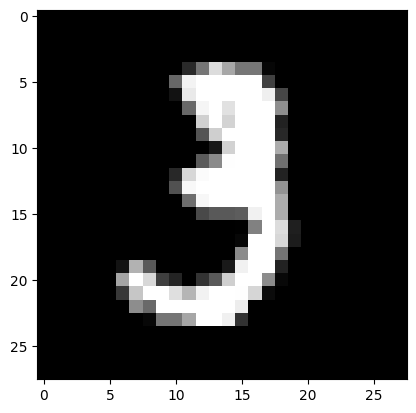

In [2]:
image, label = dataset[10]
plt.imshow(image, cmap='gray')
print('Label:', label)

In [3]:
from torchvision.transforms import transforms

# MNIST dataset(images and labels)
mnist_dataset = MNIST(root = '.data/', train = True, transform = transforms.ToTensor())
print(mnist_dataset)

Dataset MNIST
    Number of datapoints: 60000
    Root location: .data/
    Split: Train
    StandardTransform
Transform: ToTensor()


torch.Size([1, 28, 28]) 5


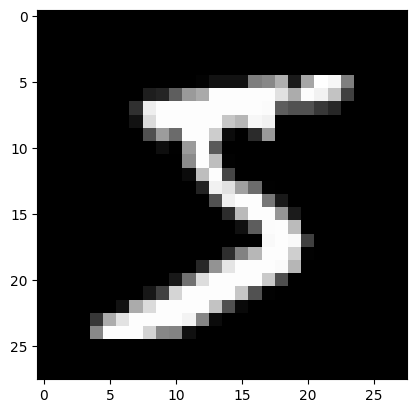

In [4]:
image_tensor, label = mnist_dataset[0]
print(image_tensor.shape, label)

plt.imshow(dataset[0][0], cmap='gray')

In [5]:
import torch

print(image_tensor[:,10:15,10:15])
print(torch.max(image_tensor), torch.min(image_tensor))

# 0 representing black, 1 white, and the values between different shades of grey

tensor([[[0.0039, 0.6039, 0.9922, 0.3529, 0.0000],
         [0.0000, 0.5451, 0.9922, 0.7451, 0.0078],
         [0.0000, 0.0431, 0.7451, 0.9922, 0.2745],
         [0.0000, 0.0000, 0.1373, 0.9451, 0.8824],
         [0.0000, 0.0000, 0.0000, 0.3176, 0.9412]]])
tensor(1.) tensor(0.)


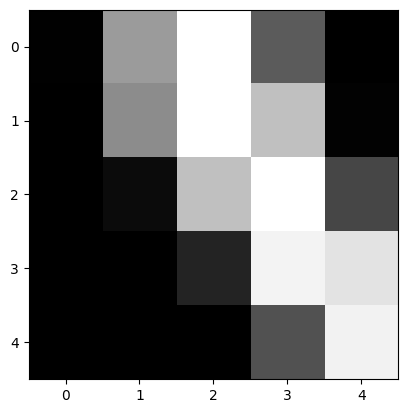

In [6]:
# Plot the image of the tensor
plt.imshow(image_tensor[0,10:15,10:15],cmap = 'gray')

In [7]:
from torch.utils.data import random_split

# Training and Validation Datasets

train_data, validation_data = random_split(mnist_dataset, [50000, 10000])
## Print the length of train and validation datasets
print("length of Train Datasets: ", len(train_data))
print("length of Validation Datasets: ", len(validation_data))

length of Train Datasets:  50000
length of Validation Datasets:  10000


In [8]:
from torch.utils.data import DataLoader

batch_size = 128
train_loader = DataLoader(train_data, batch_size, shuffle = True)
val_loader = DataLoader(validation_data, batch_size, shuffle = False)
# Since Validation dataloader is used only for evaluating the model, there is no need to shuffle the images

In [9]:
# Model
# Logistic Regression model is identical to a linear regression model.

import torch.nn as nn

input_size = 28 * 28
num_classes = 10

## Logistic regression model
model = nn.Linear(input_size, num_classes)

print(model.weight.shape)
print(model.weight)
print(model.bias.shape)
print(model.bias)

torch.Size([10, 784])
Parameter containing:
tensor([[ 0.0021, -0.0080,  0.0117,  ...,  0.0185, -0.0316,  0.0131],
        [-0.0011,  0.0154, -0.0303,  ..., -0.0282,  0.0074, -0.0312],
        [ 0.0145,  0.0312, -0.0180,  ...,  0.0128,  0.0082,  0.0281],
        ...,
        [ 0.0186, -0.0046,  0.0056,  ...,  0.0138,  0.0185,  0.0112],
        [ 0.0236, -0.0331,  0.0053,  ...,  0.0182, -0.0077,  0.0026],
        [ 0.0259, -0.0189, -0.0055,  ...,  0.0227, -0.0012,  0.0339]],
       requires_grad=True)
torch.Size([10])
Parameter containing:
tensor([ 0.0021, -0.0091, -0.0156,  0.0153,  0.0128, -0.0272,  0.0136,  0.0031,
        -0.0128,  0.0343], requires_grad=True)


In [10]:
class MnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, xb):
        xb = xb.reshape(-1, 784)
        print(xb)
        out = self.linear(xb)
        print(out)
        return(out)


In [11]:
model = MnistModel()
print(model.linear.weight.shape, model.linear.bias.shape)
list(model.parameters())

torch.Size([10, 784]) torch.Size([10])


[Parameter containing:
 tensor([[-0.0220,  0.0138, -0.0181,  ..., -0.0267,  0.0151,  0.0055],
         [ 0.0052,  0.0132, -0.0053,  ...,  0.0121,  0.0312, -0.0256],
         [-0.0021, -0.0214, -0.0249,  ..., -0.0114, -0.0208,  0.0230],
         ...,
         [-0.0113, -0.0130,  0.0313,  ...,  0.0189,  0.0003,  0.0173],
         [ 0.0168,  0.0113,  0.0258,  ..., -0.0222, -0.0237, -0.0102],
         [-0.0188, -0.0117,  0.0083,  ..., -0.0304,  0.0090,  0.0315]],
        requires_grad=True),
 Parameter containing:
 tensor([-0.0010, -0.0314, -0.0046, -0.0073, -0.0198,  0.0048, -0.0046, -0.0337,
         -0.0292,  0.0097], requires_grad=True)]

In [12]:
for images, labels in train_loader:
    outputs = model(images)
    break

print('outputs shape: ', outputs.shape)
print('Sample outputs: \n', outputs[:2].data)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
tensor([[-0.0635, -0.0868, -0.1605,  ...,  0.1165, -0.0349, -0.0953],
        [-0.1766, -0.0964,  0.0750,  ..., -0.1840,  0.2015,  0.2052],
        [ 0.2042,  0.0538,  0.3121,  ..., -0.0717, -0.1159, -0.1362],
        ...,
        [ 0.0366, -0.0049,  0.0632,  ...,  0.1065,  0.0718,  0.0012],
        [-0.0047, -0.2046, -0.1243,  ...,  0.1158,  0.0755,  0.1522],
        [-0.0708,  0.2358, -0.1428,  ..., -0.0511, -0.1703, -0.0642]],
       grad_fn=<AddmmBackward0>)
outputs shape:  torch.Size([128, 10])
Sample outputs: 
 tensor([[-0.0635, -0.0868, -0.1605, -0.1306, -0.1427,  0.0843, -0.1580,  0.1165,
         -0.0349, -0.0953],
        [-0.1766, -0.0964,  0.0750, -0.2481,  0.0774,  0.0503,  0.1911, -0.1840,
          0.2015,  0.2052]])


In [14]:
import torch.nn.functional as F

## Apply softmax for each output row
probs = F.softmax(outputs, dim = 1)

## checking at sample probabilities
print("Sample probabilities:\n", probs[:2].data)

print("\n")
## Add up the probabilities of an output row
print("Sum: ", torch.sum(probs[0]).item())
max_probs, preds = torch.max(probs, dim = 1)
print("\n")
print(preds)
print("\n")
print(max_probs)

Sample probabilities:
 tensor([[0.0999, 0.0976, 0.0907, 0.0934, 0.0923, 0.1158, 0.0909, 0.1196, 0.1028,
         0.0968],
        [0.0819, 0.0888, 0.1054, 0.0763, 0.1056, 0.1028, 0.1183, 0.0813, 0.1196,
         0.1200]])


Sum:  1.0


tensor([7, 9, 6, 9, 5, 5, 7, 4, 6, 6, 5, 6, 6, 1, 6, 7, 5, 5, 1, 5, 6, 6, 6, 5,
        9, 5, 5, 5, 6, 6, 7, 5, 2, 5, 7, 7, 6, 5, 7, 6, 4, 6, 6, 4, 5, 6, 7, 6,
        7, 5, 5, 5, 5, 5, 7, 1, 5, 2, 6, 9, 4, 5, 3, 5, 5, 5, 5, 9, 3, 6, 4, 8,
        6, 7, 9, 6, 5, 7, 7, 7, 4, 5, 7, 4, 5, 5, 1, 6, 0, 9, 6, 5, 4, 2, 6, 4,
        4, 1, 2, 5, 6, 4, 5, 5, 7, 5, 7, 6, 5, 6, 6, 5, 5, 0, 2, 3, 5, 4, 7, 6,
        2, 6, 1, 5, 1, 6, 5, 5])


tensor([0.1196, 0.1200, 0.1386, 0.1327, 0.1434, 0.1345, 0.1226, 0.1238, 0.1228,
        0.1398, 0.1239, 0.1140, 0.1322, 0.1230, 0.1356, 0.1419, 0.1316, 0.1438,
        0.1379, 0.1581, 0.1508, 0.1209, 0.1250, 0.1429, 0.1129, 0.1395, 0.1237,
        0.1424, 0.1236, 0.1134, 0.1401, 0.1470, 0.1262, 0.1187, 0.1362, 0.1305,
        0

In [15]:
labels

tensor([3, 4, 5, 6, 7, 0, 8, 7, 5, 5, 8, 4, 9, 3, 2, 3, 4, 6, 5, 9, 8, 6, 6, 3,
        3, 0, 5, 9, 9, 1, 6, 6, 6, 6, 1, 6, 2, 9, 7, 8, 7, 8, 6, 1, 0, 9, 1, 1,
        7, 0, 7, 5, 7, 7, 6, 2, 3, 4, 3, 4, 6, 9, 7, 8, 2, 2, 9, 4, 0, 3, 1, 4,
        3, 8, 4, 5, 6, 7, 4, 1, 5, 0, 1, 4, 6, 4, 3, 6, 5, 4, 2, 9, 1, 5, 3, 3,
        7, 3, 4, 8, 8, 9, 3, 8, 8, 2, 6, 8, 9, 2, 2, 0, 9, 0, 6, 3, 0, 4, 1, 0,
        5, 9, 5, 7, 5, 1, 4, 6])

In [16]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim = 1)
    return(torch.tensor(torch.sum(preds == labels).item()/ len(preds)))

print("Accuracy: ",accuracy(outputs, labels))
print("\n")
loss_fn = F.cross_entropy
print("Loss Function: ",loss_fn)
print("\n")
## Loss for the current batch
loss = loss_fn(outputs, labels)
print(loss)

Accuracy:  tensor(0.1016)


Loss Function:  <function cross_entropy at 0x0000027490A60EB0>


tensor(2.2931, grad_fn=<NllLossBackward0>)


<img src="model_training.png">

In [17]:
class MnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, xb):
        xb = xb.reshape(-1, 784)
        out = self.linear(xb)
        return(out)

    def training_step(self, batch):
        images, labels = batch
        out = self(images) ## Generate predictions
        loss = F.cross_entropy(out, labels) ## Calculate the loss
        return(loss)

    def validation_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        acc = accuracy(out, labels)
        return({'val_loss':loss, 'val_acc': acc})

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return({'val_loss': epoch_loss.item(), 'val_acc' : epoch_acc.item()})

    def epoch_end(self, epoch,result):
        print("Epoch [{}], val_loss: {:.4f}, val_acc: {:.4f}".format(epoch, result['val_loss'], result['val_acc']))


model = MnistModel()

In [18]:
def evaluate(model, val_loader):
    outputs = [model.validation_step(batch) for batch in val_loader]
    return(model.validation_epoch_end(outputs))

def fit(epochs, lr, model, train_loader, val_loader, opt_func = torch.optim.SGD):
    history = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs):

        ## Training Phas
        for batch in train_loader:
            loss = model.training_step(batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        ## Validation phase
        result = evaluate(model, val_loader)
        model.epoch_end(epoch, result)
        history.append(result)
    return(history)

In [19]:
result0 = evaluate(model, val_loader)
result0

{'val_loss': 2.322780132293701, 'val_acc': 0.12974683940410614}

In [20]:
history1 = fit(5, 0.001, model, train_loader, val_loader)

Epoch [0], val_loss: 1.9555, val_acc: 0.6254
Epoch [1], val_loss: 1.6872, val_acc: 0.7223
Epoch [2], val_loss: 1.4865, val_acc: 0.7551
Epoch [3], val_loss: 1.3344, val_acc: 0.7758
Epoch [4], val_loss: 1.2173, val_acc: 0.7894


In [21]:
history2 = fit(5, 0.001, model, train_loader, val_loader)

Epoch [0], val_loss: 1.1250, val_acc: 0.7985
Epoch [1], val_loss: 1.0507, val_acc: 0.8069
Epoch [2], val_loss: 0.9900, val_acc: 0.8130
Epoch [3], val_loss: 0.9393, val_acc: 0.8178
Epoch [4], val_loss: 0.8965, val_acc: 0.8241


In [22]:
history3 = fit(5, 0.001, model, train_loader, val_loader)

Epoch [0], val_loss: 0.8598, val_acc: 0.8279
Epoch [1], val_loss: 0.8279, val_acc: 0.8316
Epoch [2], val_loss: 0.8000, val_acc: 0.8344
Epoch [3], val_loss: 0.7754, val_acc: 0.8363
Epoch [4], val_loss: 0.7534, val_acc: 0.8380


In [23]:
history4 = fit(5, 0.001, model, train_loader, val_loader)

Epoch [0], val_loss: 0.7337, val_acc: 0.8395
Epoch [1], val_loss: 0.7160, val_acc: 0.8422
Epoch [2], val_loss: 0.6998, val_acc: 0.8447
Epoch [3], val_loss: 0.6851, val_acc: 0.8467
Epoch [4], val_loss: 0.6716, val_acc: 0.8483


Text(0.5, 1.0, 'Accuracy Vs. No. of epochs')

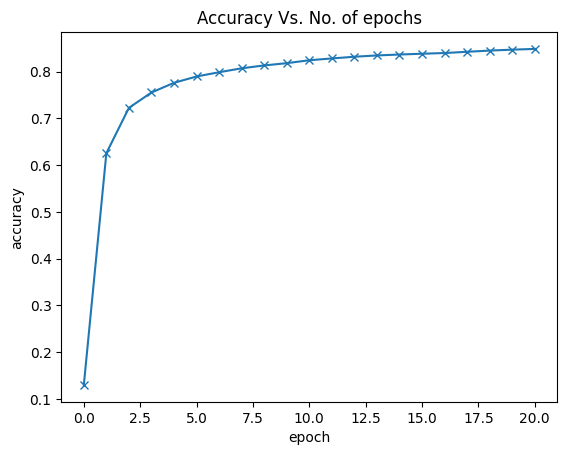

In [24]:
## Replace these values with your result
history = [result0] + history1 + history2 + history3 + history4
accuracies = [result['val_acc'] for result in history]
plt.plot(accuracies, '-x')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Accuracy Vs. No. of epochs')

In [26]:
## Define the test dataset
test_dataset = MNIST(root = '.data/', train = False, transform = transforms.ToTensor())

shape:  torch.Size([1, 28, 28])
Label:  7


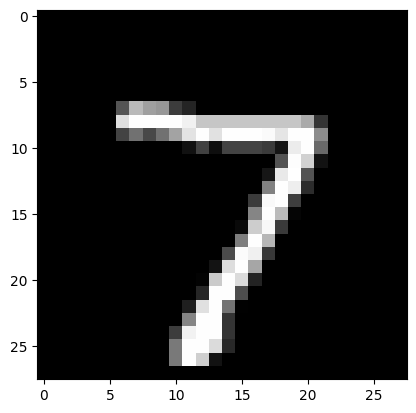

In [27]:
img, label = test_dataset[0]
plt.imshow(img[0], cmap = 'gray')
print("shape: ", img.shape)
print('Label: ', label)

In [28]:
print(img.unsqueeze(0).shape)
print(img.shape)

torch.Size([1, 1, 28, 28])
torch.Size([1, 28, 28])


In [29]:
def predict_image(img, model):
    xb = img.unsqueeze(0)
    yb = model(xb)
    _, preds = torch.max(yb, dim = 1)
    return(preds[0].item())

Label: 7 , Predicted : 7


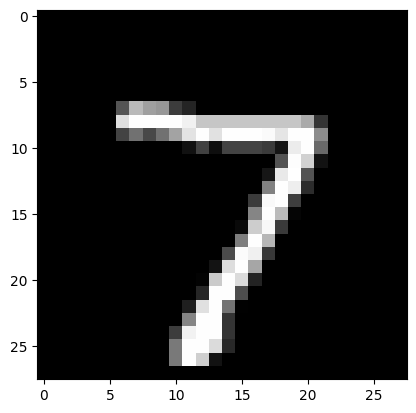

In [30]:
img, label = test_dataset[0]
plt.imshow(img[0], cmap = 'gray')
print('Label:', label, ', Predicted :', predict_image(img, model))

Label: 9 ,Predicted: 9


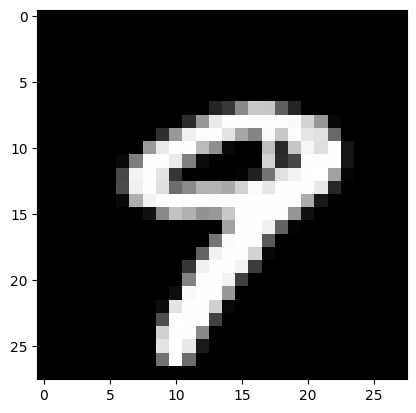

In [31]:
img, label = test_dataset[9]
plt.imshow(img[0], cmap = 'gray')
print("Label:", label, ',Predicted:', predict_image(img, model))

Label: 0 ,Predicted: 0


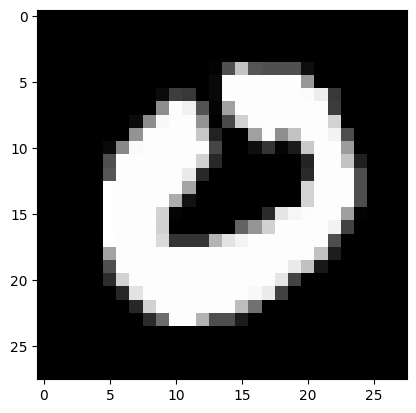

In [32]:
img, label = test_dataset[25]
plt.imshow(img[0], cmap = 'gray')
print("Label:", label, ',Predicted:', predict_image(img, model))

Label: 3 ,Predicted: 3


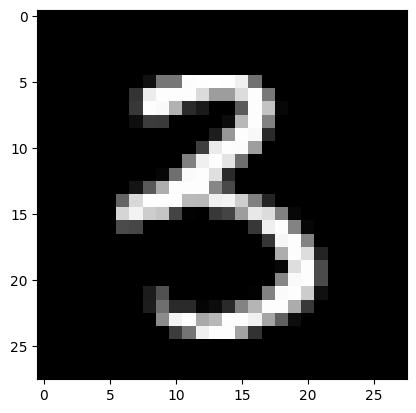

In [33]:
img, label = test_dataset[5000]
plt.imshow(img[0], cmap = 'gray')
print("Label:", label, ',Predicted:', predict_image(img, model))

In [34]:
test_loader = DataLoader(test_dataset, batch_size = 256)
result = evaluate(model, test_loader)
result

{'val_loss': 0.6426109075546265, 'val_acc': 0.85791015625}

In [35]:
# Saving and loading the Model

torch.save(model.state_dict(), 'mnist-logistic.pth')

In [36]:
model.state_dict()

OrderedDict([('linear.weight',
              tensor([[ 0.0054, -0.0186,  0.0148,  ...,  0.0019, -0.0197,  0.0110],
                      [-0.0110, -0.0320, -0.0028,  ...,  0.0132, -0.0269,  0.0149],
                      [ 0.0248,  0.0063, -0.0314,  ..., -0.0030, -0.0217, -0.0170],
                      ...,
                      [ 0.0202,  0.0272,  0.0306,  ..., -0.0272,  0.0141,  0.0022],
                      [-0.0296, -0.0260,  0.0106,  ...,  0.0269,  0.0281,  0.0119],
                      [-0.0213, -0.0177, -0.0160,  ...,  0.0270, -0.0156,  0.0232]])),
             ('linear.bias',
              tensor([-0.0551,  0.0808, -0.0391, -0.0317,  0.0559,  0.0438,  0.0161,  0.0292,
                      -0.0993, -0.0365]))])

In [37]:
model2 = MnistModel()
model2.load_state_dict(torch.load('mnist-logistic.pth'))
model2.state_dict()

OrderedDict([('linear.weight',
              tensor([[ 0.0054, -0.0186,  0.0148,  ...,  0.0019, -0.0197,  0.0110],
                      [-0.0110, -0.0320, -0.0028,  ...,  0.0132, -0.0269,  0.0149],
                      [ 0.0248,  0.0063, -0.0314,  ..., -0.0030, -0.0217, -0.0170],
                      ...,
                      [ 0.0202,  0.0272,  0.0306,  ..., -0.0272,  0.0141,  0.0022],
                      [-0.0296, -0.0260,  0.0106,  ...,  0.0269,  0.0281,  0.0119],
                      [-0.0213, -0.0177, -0.0160,  ...,  0.0270, -0.0156,  0.0232]])),
             ('linear.bias',
              tensor([-0.0551,  0.0808, -0.0391, -0.0317,  0.0559,  0.0438,  0.0161,  0.0292,
                      -0.0993, -0.0365]))])

In [38]:
test_loader = DataLoader(test_dataset, batch_size = 256)
result = evaluate(model2, test_loader)
result

{'val_loss': 0.6426109075546265, 'val_acc': 0.85791015625}